# Example: Ticker-Picker DQN at Production Scale (Advanced, Optional)

This is the Session 4 production-scale sibling of the Session 3 [Ticker-Picker DQN](../session-3/eCornell-AI-Finance-S3-Example-Optional-TickerPickerDQN-May-2026.ipynb) example. Two changes from S3 take it from a teaching toy to a setup that survives a real production loop:

* __Full S&P 500 universe.__ The S3 DQN ran on the 22-ticker minimum-variance subset because that was the universe the S3 bandit could enumerate ($2^{22} - 1 \approx 4.2$M arms). At production scale we pick from every SIM-calibrated S&P 500 ticker, around 500 names, and the action space jumps to $2^{N} \approx 10^{150}$ subsets. The combinatorial bandit physically cannot represent that table; the Q-network's parameter count is fixed by the architecture. The point of this example is that the DQN handles this regime where the bandit cannot.
* __Sentiment-trigger refire.__ The S3 DQN fired once on the chosen decision day and the basket was frozen forever. That is fine until $\lambda_t$ flips and the new regime wants a different basket. We borrow the refire protocol from the [Ticker-Picker Bandit](../session-3/eCornell-AI-Finance-S3-Example-Core-TickerPickerBandit-May-2026.ipynb) notebook: every crossing of $|\lambda_t| = \theta$ retrains the picker on that day's market state and resumes Cobb-Douglas rebalancing on the new basket. We do this for both the DQN and a sparse-bandit baseline so the comparison is apples-to-apples.

__Problem__: With $K \approx 500$ tickers there are $2^{K} - 1$ non-empty subsets the combinatorial bandit must visit, and that table cannot be allocated. The DQN reframes the same selection as a sequential decision problem: the agent starts with an empty basket and adds one ticker per step until the basket reaches a fixed size $K_{\text{basket}}$. The action space at each step is the $K - |\text{basket}|$ remaining tickers, so the total action budget per episode is $K_{\text{basket}}$, not $2^{K}$.
* __What the agent gets back.__ Intermediate rewards are zero. The terminal reward is the signed log Cobb-Douglas utility $\widetilde{U} = \mathrm{sign}(U) \cdot \log|U|$ derived from the canonical $U = \kappa \prod_{i \in \mathcal{S}} n_{i}^{\gamma_{i}}$. The signed log form preserves ranking and sign but stays bounded, the raw multiplicative form overflows at production scale ($K_{\text{basket}} = 8$, $K \sim 500$).
* __How the agent learns.__ A Q-network $Q_{\boldsymbol{\theta}}: \{0,1\}^{K} \to \mathbb{R}^{K}$ scores every ticker as a candidate next-pick from the current basket-mask state. Training uses the canonical DQN loop: a circular replay buffer, a delayed target network synced every $C$ steps, and a single Adam step per mini-batch on the squared Bellman residual. Shared parameters across the $K$ output heads mean what we learn about one basket transfers to all overlapping baskets.
* __Sparse bandit baseline.__ The standard combinatorial bandit needs an arm-mean slot for every one of the $2^K - 1$ subsets, which is impossible at this $K$. We use a sparse variant that stores arm means in a dictionary and only records the arms it has actually visited. Both pickers are constrained to baskets of size $K_{\text{basket}}$ and use the same signed log utility reward so the comparison is apples-to-apples.
* __Which data we use.__ Real prices throughout: SPY 2014-2024 training plus 2025-2026 YTD test for the SPY-derived $\lambda_t$ and $\mathbb{E}[g_m]$ inputs, and per-ticker OHLC from the extended-test dataset for the forward Cobb-Douglas walk. SIM fits ($\alpha_i, \beta_i, \sigma_{\varepsilon, i}$) come from the frozen 2014-2024 calibration loaded in the setup cell.

Let's implement this and see how it does.

> __Learning Objectives:__
>
> By the end of this example, we will be able to:
> * __Train a DQN at production scale:__ Wire the canonical DQN loop on the full S&P 500 ticker universe at the chosen decision day, train on the signed log Cobb-Douglas utility reward, and read the per-episode return curve to confirm convergence in a budget the combinatorial bandit physically cannot represent.
> * __Compare DQN to a sparse-bandit baseline on the realized forward path:__ Forward-walk the daily Cobb-Douglas rebalancing engine on each picker's basket from the chosen decision day through the end of the test data, and tabulate realized terminal wealth, max drawdown, and annualized Sharpe against the full-universe reference.
> * __Refire both pickers on regime crossings:__ Detect every crossing of $|\lambda_t| = \theta$ on the forward path, retrain both the DQN and the sparse bandit at each crossing on that day's market state, and walk the segmented Cobb-Douglas engine to compare static vs dynamic for both pickers on a single realized path.

Let's get started.
___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies, including [Flux.jl](https://fluxml.ai/Flux.jl/stable/) for the Q-network.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
The constants below set the universe + decision day, the DQN training schedule, the Q-network architecture, the sparse-bandit budget, and the sentiment refire threshold. See the inline comments for units and roles.

In [2]:
# --- Decision-day + market context (mirrors the bandit notebook) ---
B₀                    = 10_000.0                    # starting budget (USD)
Δt                    = 1.0 / 252.0                 # trading-day step (years)
L_short               = 21                          # short EMA window (days) for sentiment
L_long                = 63                          # long EMA window (days) for sentiment
L_growth              = 10                          # EMA window for the rebalancing engine's market factor
GAIN                  = 10.0                        # gain G for the λ sentiment signal
BANDIT_DECISION_DATE  = "2025-01-02"                # the calendar day we treat as "now"
BANDIT_GM_WINDOW      = 63                          # EMA window (days) for E[g_m] fed to the picker
BANDIT_EPSILON        = 0.1                         # ε-floor for negative-γ tickers in the CD utility
TRIGGER_MAX_DRAWDOWN  = 0.15                        # forward-engine drawdown gate
TRIGGER_MAX_TURNOVER  = 0.50                        # forward-engine turnover cap
RETRIGGER_LAMBDA_THRESH = 0.25                      # |λ_t| threshold for the Task 3 refire trigger

# --- DQN environment ---
K_BASKET              = 8                           # Task 1 + bandit refires basket size (apples-to-apples)
K_BASKET_DQN_REFIRE   = 16                          # Task 3 DQN-only basket size (showcases scaling beyond bandit)

# --- DQN training hyperparameters ---
HIDDEN                = 128                         # hidden width of the Q-network (wider for larger N)
BUFFER_CAPACITY       = 8_000                       # circular replay buffer capacity M
WARMUP                = 400                         # N_warm: no gradient updates until buffer ≥ this
MINIBATCH             = 128                         # B: mini-batch size per gradient step
TARGET_SYNC           = 100                         # C: copy main → target every TARGET_SYNC global steps
DISCOUNT              = 0.95f0                      # γ
LR                    = 5.0f-4                      # Adam learning rate
EPISODES              = 1600                         # number of training episodes
EPS_FLOOR             = 0.05f0                      # floor on the t^(-1/3) ε-greedy schedule

# --- Sparse-bandit comparison budget (matches the DQN's training-sample axis) ---
BANDIT_ITERS_COMPARE  = EPISODES * K_BASKET         # 1600 × 8 = 12800 transitions / iterations
BANDIT_ALPHA          = 0.1                         # constant learning rate for bandit arm-mean updates
;


### Implementation
Notebook-local helpers live here so the task cells stay short:

* `compute_basket_utility(mask, ctx)`: a thin wrapper around [`eCornellAIFinance.bandit_world`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/) that returns the **signed log Cobb-Douglas utility** $\widetilde{U} = \mathrm{sign}(U) \cdot \log|U| = \mathrm{sign}(U) \cdot \sum_{i \in \mathcal{S}} \gamma_i \log n_i$. Same ranking and sign convention as the canonical multiplicative $U = \kappa \prod_i n_i^{\gamma_i}$, but the magnitude scales linearly in the basket size and does not overflow at production $K$ and $K_{\text{basket}}$.
* `ticker_picker_world(state, action, ctx)`: one MDP step. State is the $K$-bit basket mask, action is the index of the ticker to add (already-picked tickers are masked at action-selection time). Returns `(s_next, r, done)` with $r = 0$ on intermediate steps and $r = \widetilde{U}$ on the terminal step.
* `MyReplayBuffer`, `make_qnet`, `select_action`, `dqn_train_step!`, `train_dqn`: the canonical DQN scaffolding. The Q-network is a small MLP $Q_{\boldsymbol{\theta}}:\mathbb{R}^{K} \to \mathbb{R}^{K}$ with two hidden layers of width `HIDDEN`.
* `solve_bandit_sparse(K, K_basket, n_iters, ctx)`: the sparse-Dict bandit replacement for [`solve_bandit`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.solve_bandit). Sized for huge $K$: stores arm means in a `Dict` keyed by the sorted-tuple of picked ticker indices, and constrains every arm to be a basket of exactly $K_{\text{basket}}$ tickers. Uses the same signed log utility reward as the DQN so the comparison is apples-to-apples.
* `fwd_cd(basket, rules)`: forward-walk the daily Cobb-Douglas engine on a chosen basket across the loader's `forward_price_matrix` window. Used by Task 2.
* `run_segment(B_start, basket, day_start, day_end)`: forward-walk a segment of the CD engine starting from a given wealth on a chosen basket. Used by Task 3 between refires.
* `realized_metrics(W)`: aggregate a wealth path into terminal wealth, scaled wealth, max drawdown, annualized growth, and Sharpe.

The code blocks below define each helper.

In [3]:
# --- Step 1: Signed log Cobb-Douglas utility on a basket bit-mask ---
# compute_basket_utility(mask, ctx) -> Float64
#
# At production scale (K_basket = 8, K ~ 500, possible high-α / low-β /
# low-price tickers) the canonical multiplicative form
#     U = κ · ∏_{i∈S} n_i^{γ_i}
# overflows easily, a single saturated γ ≈ 1 with n_i ≈ 10^4 contributes a
# factor of 10^4 per ticker, and 8 such factors produce |U| ≈ 10^32 or more.
# That destroys gradient stability for the DQN and makes the bandit's running
# arm-mean meaningless.
#
# We use the signed log utility as the reward instead:
#     Ũ = sign(U) · log|U| = sign(U) · Σ_{i∈S} γ_i · log n_i
# Same ranking, same sign convention (sign carries the κ flag), but the
# magnitude scales linearly in the basket size and stays in single/double
# digits for typical baskets. We compute log|U| from the (n, γ) returned by
# `eCornellAIFinance.bandit_world` rather than taking log of an already-
# overflowed product.
function compute_basket_utility(mask::AbstractVector, ctx)::Float64
    action = Int.(mask .> 0.5f0)
    sum(action) == 0 && return 0.0
    bandit_ctx = build(MyBanditContext, (
        tickers = ctx.tickers, sim_parameters = ctx.sim_parameters,
        prices = ctx.prices, B = ctx.B,
        gm_t = ctx.gm_t, lambda = ctx.lambda, epsilon = ctx.epsilon,
    ))
    (_, n, γ) = eCornellAIFinance.bandit_world(action, bandit_ctx)
    S = findall(==(1), action)
    sign_U = any(γ[i] < 0.0 for i in S) ? -1.0 : 1.0
    log_abs_U = 0.0
    @inbounds for s in S
        n[s] > 0.0 && (log_abs_U += γ[s] * log(n[s]))
    end
    return sign_U * log_abs_U
end;

In [4]:
# --- Step 2: Sequential ticker-picker MDP step ---
# ticker_picker_world(state, action, ctx) -> (s_next, r, done)
# Add ticker `action` to the current basket-mask state. Intermediate reward is 0;
# terminal reward is `compute_basket_utility(...)`. Episode terminates when the
# basket reaches `ctx.K_basket` tickers.

function ticker_picker_world(state::Vector{Float32}, action::Int, ctx)
    s_next = copy(state)
    s_next[action] = 1.0f0
    basket_size = Int(round(sum(s_next)))
    done = (basket_size >= ctx.K_basket)
    r = done ? Float32(compute_basket_utility(s_next, ctx)) : 0.0f0
    return (s_next, r, done)
end;

In [5]:
# --- Step 3: Circular replay buffer + Q-network factory ---
mutable struct MyReplayBuffer
    states::Vector{Vector{Float32}}
    actions::Vector{Int}
    rewards::Vector{Float32}
    next_states::Vector{Vector{Float32}}
    dones::Vector{Bool}
    capacity::Int
end
MyReplayBuffer(cap::Int) = MyReplayBuffer(Vector{Vector{Float32}}(), Int[], Float32[], Vector{Vector{Float32}}(), Bool[], cap)

# push_transition!(buf, s, a, r, s', d), append, FIFO-evict if at capacity.
function push_transition!(buf::MyReplayBuffer, s, a, r, s′, d)
    if length(buf.states) >= buf.capacity
        popfirst!(buf.states); popfirst!(buf.actions)
        popfirst!(buf.rewards); popfirst!(buf.next_states); popfirst!(buf.dones)
    end
    push!(buf.states, s); push!(buf.actions, a); push!(buf.rewards, r)
    push!(buf.next_states, s′); push!(buf.dones, d)
end

# make_qnet(K, H) -> Flux.Chain
# Two-hidden-layer MLP R^K -> R^H -> R^H -> R^K with `relu` activations. The
# parameter count is fixed by H and K, NOT by 2^K, this is the
# generalization that lets the DQN scale where the dense bandit cannot.
make_qnet(K::Int, H::Int) = Chain(
    Dense(K, H, relu),
    Dense(H, H, relu),
    Dense(H, K),
);

In [6]:
# --- Step 4: ε-greedy action selector with masking of already-picked tickers ---

# select_action(qnet, state, ε, K) -> Int
# ε-greedy action selection with already-picked tickers masked out: with prob ε,
# sample uniformly from the un-picked indices; otherwise argmax over qnet(state)
# restricted to the available indices.
function select_action(qnet, state::Vector{Float32}, ε::Real, K::Int)::Int
    available = findall(==(0.0f0), state)
    isempty(available) && error("no available actions: state already full")
    if rand() <= ε
        return rand(available)
    else
        Q = vec(qnet(reshape(state, :, 1)))
        @inbounds for i in 1:K
            state[i] > 0.5f0 && (Q[i] = -Inf32)
        end
        return argmax(Q)
    end
end;

In [7]:
# --- Step 5: One DQN gradient step on a sampled mini-batch ---

# dqn_train_step!(main, target, opt_state, buf, B, γ_disc, K) -> Float32
# Sample a mini-batch of B transitions from `buf`, compute bootstrap targets
# y_i = r_i + γ (1 - d_i) max_a' [Q'_{θ⁻}(s'_i)]_{a'} with the picked-ticker mask
# applied in s', and take one Adam step on the mean squared Bellman residual.
function dqn_train_step!(main, target, opt_state,
        buf::MyReplayBuffer, B::Int, γ_disc::Float32, K::Int)::Float32
    n = length(buf.states)
    n < B && return 0.0f0
    idx = rand(1:n, B)
    S_mat  = reduce(hcat, buf.states[idx])           # (K, B)
    Sn_mat = reduce(hcat, buf.next_states[idx])      # (K, B)
    rewards = buf.rewards[idx]                        # (B,)
    dones   = Float32.(buf.dones[idx])                # (B,)
    actions = buf.actions[idx]                        # (B,)

    # --- Step 5a: target Q-values, mask already-picked in s' ---
    Qn = target(Sn_mat)                               # (K, B)
    @inbounds for j in 1:B, i in 1:K
        Sn_mat[i, j] > 0.5f0 && (Qn[i, j] = -1.0f30)
    end
    max_Qn = vec(maximum(Qn, dims = 1))               # (B,)
    targets = rewards .+ γ_disc .* (1.0f0 .- dones) .* max_Qn

    # --- Step 5b: one-hot mask for the action taken ---
    A_onehot = zeros(Float32, K, B)
    @inbounds for j in 1:B
        A_onehot[actions[j], j] = 1.0f0
    end

    # --- Step 5c: one Adam step on MSE Bellman residual ---
    loss, grads = Flux.withgradient(main) do m
        Q = m(S_mat)
        Q_taken = vec(sum(Q .* A_onehot, dims = 1))
        Flux.mse(Q_taken, targets)
    end
    Flux.update!(opt_state, main, grads[1])
    return loss
end;

In [8]:
# --- Step 6: Full DQN training loop ---

# train_dqn(ctx; ...) -> (main, target, history)
# Canonical DQN loop on the ticker-picker MDP defined by `ctx`. Returns the trained
# main + target Q-networks and a NamedTuple `history` with per-episode returns,
# selected baskets, and the streaming ε schedule.
function train_dqn(ctx;
        episodes::Int, K_basket::Int, hidden::Int,
        lr::Float32, buffer_cap::Int, warmup::Int, batch_size::Int,
        sync_freq::Int, γ_disc::Float32, ε_floor::Float32)
    K = length(ctx.tickers)
    main   = make_qnet(K, hidden)
    target = make_qnet(K, hidden)
    Flux.loadmodel!(target, Flux.state(main))
    opt_state = Flux.setup(Adam(lr), main)
    buf = MyReplayBuffer(buffer_cap)

    returns = Float32[]; lengths = Int[]; baskets = Vector{Vector{Int}}()
    eps_track = Float32[]
    global_step = 0

    for ep in 1:episodes
        s = zeros(Float32, K)
        ep_return = 0.0f0; ep_len = 0
        while true
            global_step += 1
            t = global_step
            ε_raw = min(1.0f0, Float32(t)^(-1/3) * (Float32(K) * log(t + 1))^(1/3))
            ε = max(ε_floor, ε_raw)
            push!(eps_track, ε)

            a = select_action(main, s, ε, K)
            s′, r, done = ticker_picker_world(s, a, ctx)
            push_transition!(buf, s, a, r, s′, done)

            ep_return += r; ep_len += 1

            if length(buf.states) >= warmup
                dqn_train_step!(main, target, opt_state, buf, batch_size, γ_disc, K)
                global_step % sync_freq == 0 && Flux.loadmodel!(target, Flux.state(main))
            end

            s = s′
            done && break
        end
        push!(returns, ep_return); push!(lengths, ep_len)
        push!(baskets, findall(==(1.0f0), s))
    end

    history = (returns = returns, lengths = lengths,
               baskets = baskets, eps_track = eps_track)
    return (main, target, history)
end;

In [9]:
# --- Step 7: Sparse ε-greedy bandit for huge K (Dict-keyed arm means) ---
# solve_bandit_sparse(K, K_basket, n_iters, ctx; ε_floor, α) -> NamedTuple
# Replacement for `eCornellAIFinance.solve_bandit` that does NOT allocate a
# `2^K - 1`-element arm-mean vector. Restricts arms to baskets of exactly
# `K_basket` tickers (matching the DQN's episode constraint) and stores arm
# means in a Dict keyed by the sorted vector of picked ticker indices. Each
# iteration picks a basket (ε-greedy: random size-K_basket subset on explore,
# best-mean-so-far on exploit), evaluates `compute_basket_utility`, and
# updates the running mean.
function solve_bandit_sparse(K::Int, K_basket::Int, n_iters::Int, ctx;
        ε_floor::Float64 = 0.05, α::Float64 = 0.1)
    arm_mean  = Dict{Vector{Int},Float64}()
    arm_count = Dict{Vector{Int},Int}()
    rewards   = zeros(Float64, n_iters)
    eps_hist  = zeros(Float64, n_iters)

    random_basket() = sort!(randperm(K)[1:K_basket])

    for t in 1:n_iters
        ε = max(ε_floor, t > 1 ? min(1.0, t^(-1.0/3.0) * (K_basket * log(t))^(1.0/3.0)) : 1.0)
        eps_hist[t] = ε

        basket = if rand() < ε || isempty(arm_mean)
            random_basket()
        else
            argmax(arm_mean)
        end

        # --- Evaluate U(basket) via compute_basket_utility on the K-bit mask ---
        mask = zeros(Float32, K)
        for i in basket
            mask[i] = 1.0f0
        end
        U = compute_basket_utility(mask, ctx)

        c = get(arm_count, basket, 0) + 1
        arm_count[basket] = c
        old = get(arm_mean, basket, 0.0)
        lr = α > 0.0 ? α : 1.0 / c
        arm_mean[basket] = old + lr * (U - old)
        rewards[t] = U
    end

    best_basket = argmax(arm_mean)
    best_action = zeros(Int, K)
    for i in best_basket
        best_action[i] = 1
    end
    best_mask = Float32.(best_action)
    best_utility = compute_basket_utility(best_mask, ctx)

    return (best_action = best_action, best_utility = best_utility,
            best_basket = best_basket,
            reward_history = rewards, exploration_history = eps_hist,
            n_unique_arms = length(arm_mean))
end;

Three more notebook-local helpers used by Tasks 2 and 3:

* `fwd_cd(basket, rules)` and `run_segment(B_start, basket, day_start, day_end)`: forward-walk the daily Cobb-Douglas rebalancing engine on a chosen basket. `fwd_cd` runs the full forward window from $W_0 = B_0$ (Task 2's static-basket walk); `run_segment` runs a slice of the window from a given starting wealth (Task 3's per-segment walk between refires). Both read the loader-cell globals `forward_price_matrix`, `forward_lambda`, `forward_gm_ema`, `my_tickers`, `sim_params`, and the constants `B₀`, `Δt`.
* `walk_refire_segments(baskets, boundaries, n_fwd, B_start)`: stitch a sequence of segments into one wealth path, carrying wealth continuously across refire boundaries. Used by Task 3 to walk both the DQN's and the bandit's dynamic strategies after the per-segment baskets are decided.
* `realized_metrics(W)`: aggregate a wealth-path vector into terminal wealth, scaled wealth, max drawdown, annualized continuously compounded growth rate, and Sharpe ratio.

In [10]:
# --- Step 8: Forward-walk Cobb-Douglas helpers ---

"""
    fwd_cd(basket, rules) -> Vector{Float64}

Forward-walk the daily Cobb-Douglas rebalancing engine over the full forward
window on a chosen basket of tickers, starting from the initial budget `B₀`.
Used by Task 2's static-basket comparison.

### Arguments
- `basket::Vector{String}`: the tickers to rebalance within.
- `rules::MyTriggerRules`: drawdown / turnover trigger rules built in the caller.

### Returns
- `Vector{Float64}`: wealth path of length `size(forward_price_matrix, 1)`.

Reads loader-cell globals: `my_tickers`, `sim_params`, `forward_price_matrix`,
`forward_gm_ema`, `forward_lambda`, plus the constants `B₀` and `Δt`.
"""
function fwd_cd(basket::Vector{String}, rules)
    sel_idx = findall(in(basket), my_tickers)
    sel_sim = Dict(t => sim_params[t] for t in basket)
    sel_p   = forward_price_matrix[:, vcat([1], sel_idx .+ 1)]
    ctx = build(MyRebalancingContextModel, (
        B = B₀, tickers = basket, marketdata = sel_p,
        marketfactor = forward_gm_ema, sim_parameters = sel_sim,
        lambda = forward_lambda[1], Δt = Δt, epsilon = 0.1,
    ));
    res = run_rebalancing_engine(ctx, rules, forward_lambda;
        offset = 1, allocator = :cobb_douglas);
    return compute_wealth_series(res, sel_p, basket; offset = 1)
end;

"""
    run_segment(B_start, basket, day_start, day_end) -> Vector{Float64}

Forward-walk the daily Cobb-Douglas engine on a slice of the forward window,
starting from a given wealth `B_start`. Used by Task 3 to walk one segment
between refire boundaries.

### Arguments
- `B_start::Float64`: starting wealth at `day_start`.
- `basket::Vector{String}`: tickers to rebalance within for this segment.
- `day_start::Int`, `day_end::Int`: inclusive segment endpoints (indices into the forward window).

### Returns
- `Vector{Float64}`: wealth path on the segment.

Reads the same loader-cell globals as `fwd_cd`.
"""
function run_segment(B_start::Float64, basket::Vector{String},
        day_start::Int, day_end::Int)::Vector{Float64}
    sel_idx     = findall(in(basket), my_tickers);
    sel_sim     = Dict(t => sim_params[t] for t in basket);
    sel_pmat    = forward_price_matrix[day_start:day_end, vcat([1], sel_idx .+ 1)];
    sub_lambda  = forward_lambda[day_start:day_end];
    sub_gm_ema  = forward_gm_ema[day_start:day_end];
    n_seg       = day_end - day_start + 1;
    n_seg < 2 && return [B_start];
    ctx = build(MyRebalancingContextModel, (
        B = B_start, tickers = basket, marketdata = sel_pmat,
        marketfactor = sub_gm_ema, sim_parameters = sel_sim,
        lambda = sub_lambda[1], Δt = Δt, epsilon = 0.1,
    ));
    rules_seg = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN,
        max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, n_seg - 1)
    ));
    res = run_rebalancing_engine(ctx, rules_seg, sub_lambda; offset = 1, allocator = :cobb_douglas);
    return compute_wealth_series(res, sel_pmat, basket; offset = 1)
end;

"""
    walk_refire_segments(baskets, boundaries, n_fwd, B_start) -> Vector{Float64}

Stitch a sequence of segments together into one wealth path across the full
forward window. Each segment uses the basket at the matching index and starts
from the wealth that survived the previous segment, so wealth carries
continuously across refire boundaries. Used by Task 3 to walk both the DQN's
and the bandit's dynamic strategies.

### Arguments
- `baskets::Vector{Vector{String}}`: one basket per segment (length = number of segments).
- `boundaries::Vector{Int}`: segment endpoints; segment `k` covers `boundaries[k] : boundaries[k+1]-1`.
- `n_fwd::Int`: total length of the forward window.
- `B_start::Float64`: initial wealth at the first segment's start day.

### Returns
- `Vector{Float64}`: wealth path of length `n_fwd`.
"""
function walk_refire_segments(baskets::Vector{Vector{String}},
        boundaries::Vector{Int}, n_fwd::Int, B_start::Float64)::Vector{Float64}
    wealth = zeros(n_fwd)
    W_running = B_start
    for k in 1:length(boundaries) - 1
        seg_start = boundaries[k]
        seg_end   = boundaries[k + 1] - 1
        seg_wealth = run_segment(W_running, baskets[k], seg_start, seg_end)
        wealth[seg_start:seg_end] .= seg_wealth
        W_running = seg_wealth[end]
    end
    return wealth
end;

# --- Step 9: Realized-metrics aggregator on a wealth path ---

"""
    realized_metrics(W) -> NamedTuple

Aggregate a wealth path into a scorecard NamedTuple with terminal wealth,
scaled wealth, max drawdown, annualized continuously compounded growth, and
Sharpe ratio.

### Arguments
- `W::Vector{Float64}`: wealth path.

### Returns
- `NamedTuple` with fields `W_T`, `W_T_over_W0`, `max_dd`, `ann_ret`, `sharpe`.

Reads loader-cell globals `B₀` and `g_f`.
"""
function realized_metrics(W::Vector{Float64})
    ret    = diff(W) ./ W[1:end-1]
    peak   = accumulate(max, W)
    max_dd = maximum((peak .- W) ./ peak)
    vol    = std(ret) * sqrt(252)
    ann_ret = log(W[end] / W[1]) * (252.0 / (length(W) - 1))
    sharpe  = vol > 1e-6 ? (ann_ret - g_f) / vol : 0.0
    return (W_T = W[end], W_T_over_W0 = W[end] / B₀, max_dd = max_dd,
            ann_ret = ann_ret, sharpe = sharpe)
end;

Load the full S&P 500 SIM calibration and the real OHLC datasets we will use throughout. Unlike the Session 3 DQN notebook (which used the 22-ticker `minvar-allocation` subset), we pull the universe from [`MySIMCalibration()`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/) and intersect it with the tickers that have full OHLC coverage on every forward day. The rest of the loader mirrors the bandit notebook: concatenate 2014-2024 training SPY with 2025-2026 YTD test SPY, find `BANDIT_DECISION_DATE` in the combined timeline, pre-compute the inputs to the picker reward function and to the forward Cobb-Douglas engine.

> __What does the code block below load?__
>
> The cell returns:
>
> * `my_tickers::Vector{String}`: full ticker universe (intersection of SIM calibration and OHLC full coverage).
> * `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: per-ticker SIM fits.
> * `g_f::Float64`: continuously compounded annual risk-free rate (1/yr).
> * `K::Int`: number of tickers in the universe.
> * `bandit_decision_date::DateTime`: the resolved decision day from `BANDIT_DECISION_DATE`.
> * `bandit_λ::Float64`, `bandit_gm_t::Float64`, `bandit_prices::Vector{Float64}`: snapshot inputs to the picker reward function at the decision day.
> * `forward_dates::Vector{DateTime}`, `forward_price_matrix::Matrix{Float64}`, `forward_lambda::Vector{Float64}`, `forward_gm_ema::Vector{Float64}`: forward arrays for the daily CD engine.
> * `forward_gm_ema_bandit::Vector{Float64}`: 63-day EMA of `compute_market_growth` over the same forward window, used as `gm_t` when Task 3 refires the pickers.

In [11]:
(; my_tickers, sim_params, g_f, K,
   bandit_decision_date, bandit_λ, bandit_gm_t, bandit_prices,
   forward_dates, forward_price_matrix, forward_lambda, forward_gm_ema,
   forward_gm_ema_bandit) = let

    # --- Step 1: Load full-universe SIM calibration ---
    calib = MySIMCalibration();
    sim_tickers = calib["tickers"]::Vector{String};
    α_vec = calib["alpha"]::Vector{Float64};
    β_vec = calib["beta"]::Vector{Float64};
    σ_vec = calib["sigma_eps"]::Vector{Float64};
    sim_full = Dict{String,Tuple{Float64,Float64,Float64}}(
        sim_tickers[i] => (α_vec[i], β_vec[i], σ_vec[i]) for i in eachindex(sim_tickers)
    );
    g_f = 0.045;  # Session 1 risk-free rate convention (CCGR /yr)

    # --- Step 2: Real SPY history (training + extended test) ---
    train_spy = MyTrainingMarketDataSet()["dataset"]["SPY"];
    test_spy  = MyExtendedTestingMarketDataSet()["dataset"]["SPY"];
    spy_full  = vcat(train_spy, test_spy);
    sort!(spy_full, :timestamp); unique!(spy_full, :timestamp);

    target_date = Date(BANDIT_DECISION_DATE);
    bandit_decision_t = findfirst(==(target_date), Date.(spy_full.timestamp));
    isnothing(bandit_decision_t) && error("BANDIT_DECISION_DATE=$(BANDIT_DECISION_DATE) not found in SPY history");
    bandit_decision_date = spy_full.timestamp[bandit_decision_t];

    # --- Step 3: λ_t and gm_t at the decision day ---
    spy_history = spy_full.close[1:bandit_decision_t];
    λ_real = compute_lambda(
        compute_ema(spy_history; window = L_short),
        compute_ema(spy_history; window = L_long); G = GAIN);
    gm_ema_real = compute_ema(
        compute_market_growth(spy_history; Δt = Δt); window = BANDIT_GM_WINDOW);
    bandit_λ    = λ_real[end];
    bandit_gm_t = gm_ema_real[end];

    # --- Step 4: Intersect SIM universe with tickers that have full forward OHLC ---
    test_ds = MyExtendedTestingMarketDataSet()["dataset"];
    forward_dates_full = spy_full.timestamp[bandit_decision_t:end];
    target_dates_fwd   = Date.(forward_dates_full);
    n_fwd              = length(forward_dates_full);

    keep = String[];
    for t in sim_tickers
        haskey(test_ds, t) || continue
        df = test_ds[t]
        df_dates = Date.(df.timestamp)
        # require coverage on the decision day AND every forward day
        ok_decision = !isnothing(findfirst(==(target_date), df_dates))
        ok_decision || continue
        ok_fwd = all(d -> !isnothing(findfirst(==(d), df_dates)), target_dates_fwd)
        ok_fwd && push!(keep, t)
    end
    my_tickers = sort(keep)
    sim_params = Dict(t => sim_full[t] for t in my_tickers)
    K = length(my_tickers);

    # --- Step 5: Per-ticker prices on the decision day ---
    bandit_prices = zeros(K);
    for (k, t) in enumerate(my_tickers)
        df = test_ds[t]
        i  = findfirst(==(target_date), Date.(df.timestamp))
        bandit_prices[k] = df.close[i]
    end

    # --- Step 6: Forward arrays for the CD engine (engine gm_ema is the 10-day window) ---
    λ_full      = compute_lambda(
        compute_ema(spy_full.close; window = L_short),
        compute_ema(spy_full.close; window = L_long); G = GAIN);
    gm_full     = compute_market_growth(spy_full.close; Δt = Δt);
    gm_ema_full = compute_ema(gm_full; window = L_growth);
    gm_ema_bandit_full = compute_ema(gm_full; window = BANDIT_GM_WINDOW);

    forward_dates  = forward_dates_full;
    forward_lambda = λ_full[bandit_decision_t:end];
    forward_gm_ema = gm_ema_full[bandit_decision_t-1:end];
    forward_gm_ema_bandit = gm_ema_bandit_full[bandit_decision_t-1:end];

    forward_price_matrix = zeros(n_fwd, K + 1);
    forward_price_matrix[:, 1] = 1:n_fwd;
    for (k, t) in enumerate(my_tickers)
        df = test_ds[t]; df_dates = Date.(df.timestamp)
        for (day, d) in enumerate(target_dates_fwd)
            i = findfirst(==(d), df_dates)
            forward_price_matrix[day, k + 1] = df.close[i]
        end
    end

    println("SIM-calibrated tickers: $(length(sim_tickers))")
    println("After OHLC full-coverage filter: $(K) tickers (action space ≈ 2^$(K) baskets)")
    println("Decision day: $(Date(bandit_decision_date))")
    println("  gm_t = $(round(bandit_gm_t, digits=3)) /yr   λ = $(round(bandit_λ, digits=3))")
    println("Forward window: $(Date(forward_dates[1])) → $(Date(forward_dates[end]))  ($(n_fwd) trading days)")

    (my_tickers = my_tickers, sim_params = sim_params, g_f = g_f, K = K,
     bandit_decision_date = bandit_decision_date,
     bandit_λ = bandit_λ, bandit_gm_t = bandit_gm_t, bandit_prices = bandit_prices,
     forward_dates = forward_dates, forward_price_matrix = forward_price_matrix,
     forward_lambda = forward_lambda, forward_gm_ema = forward_gm_ema,
     forward_gm_ema_bandit = forward_gm_ema_bandit)
end;

SIM-calibrated tickers: 424
After OHLC full-coverage filter: 413 tickers (action space ≈ 2^413 baskets)
Decision day: 2025-01-02
  gm_t = -0.045 /yr   λ = -0.116
Forward window: 2025-01-02 → 2026-04-22  (326 trading days)


___
## Task 1: Train DQN and the Sparse Bandit on the Full Universe
In this task, we train the DQN on the full S&P 500 universe at `BANDIT_DECISION_DATE` and run the sparse-Dict bandit on the same problem with a matched training-sample budget. Both pickers are constrained to baskets of exactly `K_BASKET` tickers so the comparison is apples-to-apples.

> __What should we see?__
>
> The bandit's exploration budget is `BANDIT_ITERS_COMPARE` random size-$K_{\text{b}}$ subsets out of $\binom{K}{K_{\text{b}}}$ possibilities, which at this $K$ is astronomically large; with $\varepsilon$-greedy it almost certainly never visits the same arm twice and its `best_arm` is essentially the best random sample. The DQN's per-episode return $G_e$ should rise as the network learns to score high-$\gamma_i$ tickers from the empty-basket state and converge to a basket whose Cobb-Douglas utility is meaningfully higher than the bandit's best-found arm.

The code block below builds the picker reward context, trains the DQN, runs the sparse bandit, and stores them in `dqn_main`, `dqn_history`, `bandit_result`, `dqn_basket`, and `bandit_basket`.

In [12]:
(; dqn_main, dqn_history, bandit_result, dqn_basket, bandit_basket) = let
    Random.seed!(2026)

    # --- Step 1: Build the picker reward context (used by both DQN and bandit) ---
    picker_ctx = (tickers = my_tickers, sim_parameters = sim_params,
                  prices = bandit_prices, B = B₀,
                  gm_t = bandit_gm_t, lambda = bandit_λ,
                  epsilon = BANDIT_EPSILON, K_basket = K_BASKET)

    # --- Step 2: Train the DQN agent on the full universe ---
    println("Training DQN on K=$(K) tickers, episodes=$(EPISODES), basket size=$(K_BASKET) ...")
    main, _target, history = train_dqn(picker_ctx;
        episodes    = EPISODES,
        K_basket    = K_BASKET,
        hidden      = HIDDEN,
        lr          = LR,
        buffer_cap  = BUFFER_CAPACITY,
        warmup      = WARMUP,
        batch_size  = MINIBATCH,
        sync_freq   = TARGET_SYNC,
        γ_disc      = DISCOUNT,
        ε_floor     = EPS_FLOOR)

    # --- Step 3: Read off the DQN's deployed basket via greedy rollout ---
    s = zeros(Float32, K); picked = Int[]
    for _ in 1:K_BASKET
        a = select_action(main, s, 0.0f0, K)  # ε = 0 → pure greedy
        push!(picked, a); s[a] = 1.0f0
    end
    dqn_basket = my_tickers[picked]
    dqn_utility = compute_basket_utility(s, picker_ctx)

    # --- Step 4: Run the sparse-bandit baseline at the same decision day ---
    println("Running sparse bandit, $(BANDIT_ITERS_COMPARE) iterations ...")
    bandit_result = solve_bandit_sparse(K, K_BASKET, BANDIT_ITERS_COMPARE, picker_ctx;
        ε_floor = Float64(EPS_FLOOR), α = BANDIT_ALPHA)
    bandit_basket = my_tickers[bandit_result.best_basket]

    # --- Step 5: Report (Ũ = signed log Cobb-Douglas utility) ---
    println("DQN basket   ($(length(dqn_basket))): $(dqn_basket)")
    println("  greedy-rollout Ũ = $(round(dqn_utility, digits=4))")
    println("Bandit basket ($(length(bandit_basket))): $(bandit_basket)")
    println("  best-arm Ũ = $(round(bandit_result.best_utility, digits=4))")
    println("  bandit visited $(bandit_result.n_unique_arms) unique arms out of ≈C($(K),$(K_BASKET)) possible")

    (dqn_main = main, dqn_history = history, bandit_result = bandit_result,
     dqn_basket = dqn_basket, bandit_basket = bandit_basket)
end;

Training DQN on K=413 tickers, episodes=1600, basket size=8 ...
Running sparse bandit, 12800 iterations ...
DQN basket   (8): ["IBM", "LOW", "O", "DTE", "F", "TER", "TMO", "AOS"]
  greedy-rollout Ũ = -1.4755
Bandit basket (8): ["CMG", "DHR", "ISRG", "MCK", "MRK", "PWR", "STE", "UNH"]
  best-arm Ũ = -0.1273
  bandit visited 3254 unique arms out of ≈C(413,8) possible


The code block below plots both training trajectories on a common training-sample axis: bandit iterations $1, 2, \ldots, T$ and DQN episode boundaries at multiples of $K_{\text{basket}}$. A 25-point rolling mean smooths each trace; the bandit's `best_utility` and the DQN's deployed-greedy utility appear as horizontal references.

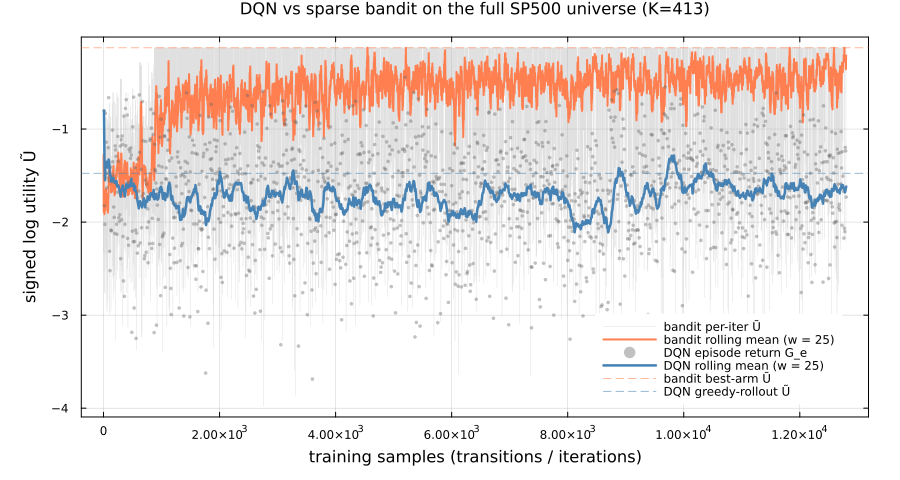

In [13]:
let
    G_dqn = dqn_history.returns
    n_ep = length(G_dqn)
    dqn_x = collect(K_BASKET:K_BASKET:K_BASKET*n_ep)

    bandit_R = bandit_result.reward_history
    bandit_x = collect(1:length(bandit_R))

    rolling(v, w) = [mean(@view v[max(1, i - w + 1):i]) for i in 1:length(v)]
    w = 25
    rolling_dqn = rolling(G_dqn, w)
    rolling_bnd = rolling(bandit_R, w)

    p = plot(bandit_x, bandit_R; c = :gray70, lw = 0.5, alpha = 0.4,
        label = "bandit per-iter Ũ",
        xlabel = "training samples (transitions / iterations)",
        ylabel = "signed log utility Ũ",
        title = "DQN vs sparse bandit on the full SP500 universe (K=$(K))",
        titlefontsize = 11, framestyle = :box, fg_legend = :transparent,
        legend = :bottomright)
    plot!(p, bandit_x, rolling_bnd; c = :coral, lw = 2.0,
        label = "bandit rolling mean (w = $(w))")
    scatter!(p, dqn_x, G_dqn; ms = 2.0, msw = 0, c = :gray40, alpha = 0.4,
        label = "DQN episode return G_e")
    plot!(p, dqn_x, rolling_dqn; c = :steelblue, lw = 2.5,
        label = "DQN rolling mean (w = $(w))")

    hline!(p, [bandit_result.best_utility]; c = :coral, ls = :dash, lw = 0.8,
        alpha = 0.7, label = "bandit best-arm Ũ")
    s_g = zeros(Float32, K)
    for t in dqn_basket
        s_g[findfirst(==(t), my_tickers)] = 1.0f0
    end
    dqn_U = compute_basket_utility(s_g,
        (tickers = my_tickers, sim_parameters = sim_params,
         prices = bandit_prices, B = B₀,
         gm_t = bandit_gm_t, lambda = bandit_λ, epsilon = BANDIT_EPSILON))
    hline!(p, [dqn_U]; c = :steelblue, ls = :dash, lw = 0.8, alpha = 0.7,
        label = "DQN greedy-rollout Ũ")

    plot(p; size = (900, 480),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

___
## Task 2: Forward CD Rebalancing on the Picker Baskets (Real Data, Static)
In this task, we forward-walk the Cobb-Douglas rebalancing engine from `BANDIT_DECISION_DATE` through the end of the test data on **real** prices, with each picker's basket frozen at the Task 1 pick. We compare three strategies on the same forward path:

* __DQN + CD:__ Daily Cobb-Douglas rebalancing within `dqn_basket`.
* __Bandit + CD:__ Daily Cobb-Douglas rebalancing within `bandit_basket`.
* __Full-Universe CD:__ Daily Cobb-Douglas rebalancing across all $K$ tickers, no basket selection. Reference baseline.

> __What should we see?__
>
> Whether either picker beats Full-Universe on this realized forward path is a function of *which* basket each picked at the decision day plus *how the market evolved* over the next 16 months. The point of the comparison is not that the picker always wins, but that the DQN basket was found in a regime ($K = 500$) where the standard combinatorial bandit cannot even allocate its arm-mean table.

The code block below returns `forward_results::Dict{String,Vector{Float64}}` with each strategy's wealth path and `forward_summary::DataFrame` with realized terminal wealth, max drawdown, and annualized Sharpe.

In [14]:
(; forward_results, forward_summary) = let
    n_fwd = size(forward_price_matrix, 1)
    T_trade = n_fwd - 1
    rules = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, T_trade)
    ));

    # --- Step 1: DQN + CD ---
    wealth_dqn = fwd_cd(dqn_basket, rules)

    # --- Step 2: Bandit + CD ---
    wealth_bandit = isempty(bandit_basket) ? fill(B₀, n_fwd) : fwd_cd(bandit_basket, rules)

    # --- Step 3: Full-Universe CD ---
    ctx_full = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = forward_price_matrix,
        marketfactor = forward_gm_ema, sim_parameters = sim_params,
        lambda = forward_lambda[1], Δt = Δt, epsilon = 0.1,
    ));
    res_full = run_rebalancing_engine(ctx_full, rules, forward_lambda;
        offset = 1, allocator = :cobb_douglas);
    wealth_full = compute_wealth_series(res_full, forward_price_matrix, my_tickers; offset = 1)

    # --- Step 4: Realized metrics ---
    m_dqn  = realized_metrics(wealth_dqn)
    m_bnd  = realized_metrics(wealth_bandit)
    m_full = realized_metrics(wealth_full)

    forward_summary = DataFrame(
        "Strategy"        => ["DQN + CD", "Bandit + CD", "Full-Universe CD"],
        "Tickers"         => [length(dqn_basket), length(bandit_basket), K],
        "W_T (\$)"         => [round(m.W_T, digits = 0)              for m in (m_dqn, m_bnd, m_full)],
        "W_T / W₀"        => [round(m.W_T_over_W0, digits = 3)       for m in (m_dqn, m_bnd, m_full)],
        "Max DD (%)"      => [round(m.max_dd * 100, digits = 1)      for m in (m_dqn, m_bnd, m_full)],
        "Ann. return (%)" => [round(m.ann_ret * 100, digits = 2)     for m in (m_dqn, m_bnd, m_full)],
        "Sharpe"          => [round(m.sharpe, digits = 3)            for m in (m_dqn, m_bnd, m_full)],
    )
    println("Real forward run: $(Date(forward_dates[1])) → $(Date(forward_dates[end]))  ($(n_fwd) trading days)")
    pretty_table(forward_summary; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    forward_results = Dict(
        "DQN + CD"         => wealth_dqn,
        "Bandit + CD"      => wealth_bandit,
        "Full-Universe CD" => wealth_full,
    )
    (forward_results = forward_results, forward_summary = forward_summary)
end;

Real forward run: 2025-01-02 → 2026-04-22  (326 trading days)
 ------------------ --------- --------- ---------- ------------ ----------------- ---------
          Strategy   Tickers   W_T ($)   W_T / W₀   Max DD (%)   Ann. return (%)    Sharpe 
            String     Int64   Float64    Float64      Float64           Float64   Float64 
 ------------------ --------- --------- ---------- ------------ ----------------- ---------
          DQN + CD         8   13037.0      1.304          7.9             20.57     1.289
       Bandit + CD         8    8689.0      0.869         15.2            -10.89    -1.905
  Full-Universe CD       413   11656.0      1.166         13.1             11.88      0.49
 ------------------ --------- --------- ---------- ------------ ----------------- ---------


The code block below plots the three forward wealth paths on a common timeline, scaled to $W/W_{0}$, with a reference line at 1.0.

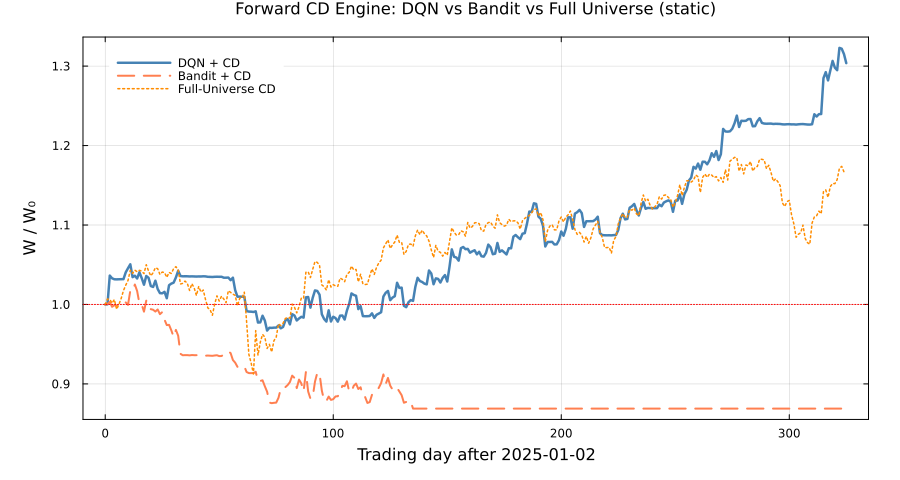

In [15]:
let
    plt = plot(xlabel = "Trading day after $(Date(bandit_decision_date))",
               ylabel = "W / W₀", title = "Forward CD Engine: DQN vs Bandit vs Full Universe (static)",
               titlefontsize = 11, legend = :topleft, framestyle = :box, fg_legend = :transparent)
    style = Dict(
        "DQN + CD"         => (color = :steelblue,  lw = 2.5),
        "Bandit + CD"      => (color = :coral,      lw = 2.0, linestyle = :dash),
        "Full-Universe CD" => (color = :darkorange, lw = 1.5, linestyle = :dot),
    )
    for label in ["DQN + CD", "Bandit + CD", "Full-Universe CD"]
        W = forward_results[label]
        plot!(plt, 0:(length(W) - 1), W ./ B₀; label = label, style[label]...)
    end
    hline!(plt, [1.0]; c = :red, ls = :dot, label = "")
    plot(plt; size = (900, 480),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Why does a wealth path go flat and never recover?

A flat plateau is the drawdown trigger going to cash. Cash earns nothing in this model, so once we trip, the wealth sits below the old peak forever and the trigger keeps firing on every subsequent bar. There is no re-entry rule.

Task 3's refires sidestep this. Each refire starts a fresh segment with the drawdown clock reset, and the picker is forced to allocate from cash on day one of the segment. The contrast on the chart is a stop-loss without a re-entry rule versus a stop-loss that gets reset whenever the regime forces a refire.

___
## Task 3: Refire Both Pickers on a Sentiment Trigger
In this task, we relax the static-basket assumption. Task 2 froze each picker's basket at `BANDIT_DECISION_DATE` and let it run for the next 326 trading days; that is fine in steady regimes and wrong when the world flips underneath us. 

We borrow the refire protocol from the [Ticker-Picker Bandit](../session-3/eCornell-AI-Finance-S3-Example-Core-TickerPickerBandit-May-2026.ipynb) notebook: every crossing of $|\lambda_t| = \theta$ (`RETRIGGER_LAMBDA_THRESH`, default 0.25) **retrains both pickers** at that day's market state and resumes Cobb-Douglas rebalancing on the new basket. Wealth carries continuously across segment boundaries.

> __Why give the DQN a bigger basket here?__
>
> Task 1 held both pickers to `K_BASKET = 8` to keep the convergence comparison apples-to-apples. At refire we drop that constraint for the DQN: it now picks `K_BASKET_DQN_REFIRE` tickers per fire (default 16), while the sparse bandit stays at `K_BASKET`. 
> 
> __Why__? The reason is structural; the bandit's `Dict` of visited arms grows combinatorially in basket size and its sparse coverage of $\binom{K}{K_b}$ baskets gets worse as $K_b$ rises, so giving it more picks would hurt rather than help. The DQN's parameter count is independent of basket size; its only cost is `K_basket` extra transitions per episode. The bigger DQN basket is the regime where the DQN's structural advantage shows up most clearly.

__Why retrain both pickers?__ The bandit refire protocol is canonical in S3 because the bandit has no other choice; without retraining, its arm means are fixed at the prior decision day's reward. 

The DQN could in principle just be re-queried at the new decision day with new $\gamma_i$ inputs (the Q-function generalizes across baskets), but the simplest fair comparison is to give both pickers the same refire budget at each crossing. We discuss the zero-shot redeploy variant in the Summary as the natural follow-up.



In [16]:
(; dynamic_results) = let
    θ = RETRIGGER_LAMBDA_THRESH;
    n_fwd = length(forward_lambda);

    # --- Step 1: Detect every crossing of the |λ_t| = θ boundary ---
    prev_above = abs(forward_lambda[1]) > θ;
    fire_idx = Int[];
    for t in 2:n_fwd
        cur_above = abs(forward_lambda[t]) > θ;
        cur_above != prev_above && push!(fire_idx, t);
        prev_above = cur_above;
    end

    # --- Step 2: For each fire day, retrain BOTH pickers at that day's market state ---
    # Refire training budget is reduced from the Task 1 budget for economy; this is the
    # production-style trade-off (faster re-fits over a richer initial fit).
    # The DQN gets a LARGER basket here (K_BASKET_DQN_REFIRE) than the bandit (K_BASKET):
    # the bandit's sparse-Dict storage caps its scalable basket size, while the DQN's
    # parameter count is independent of basket size and stays runnable.
    REFIRE_EPISODES = 300
    REFIRE_BANDIT_ITERS = REFIRE_EPISODES * K_BASKET

    dqn_baskets    = [dqn_basket]
    bandit_baskets = [bandit_basket]

    for fire_t in fire_idx
        # --- DQN fire context: bigger basket size (K_BASKET_DQN_REFIRE) ---
        dqn_fire_ctx = (tickers = my_tickers, sim_parameters = sim_params,
                        prices = forward_price_matrix[fire_t, 2:end], B = B₀,
                        gm_t = forward_gm_ema_bandit[fire_t],
                        lambda = forward_lambda[fire_t],
                        epsilon = BANDIT_EPSILON, K_basket = K_BASKET_DQN_REFIRE)

        # --- Bandit fire context: original basket size (K_BASKET) ---
        bnd_fire_ctx = (tickers = my_tickers, sim_parameters = sim_params,
                        prices = forward_price_matrix[fire_t, 2:end], B = B₀,
                        gm_t = forward_gm_ema_bandit[fire_t],
                        lambda = forward_lambda[fire_t],
                        epsilon = BANDIT_EPSILON, K_basket = K_BASKET)

        # --- DQN refire: retrain from scratch at this day, K_BASKET_DQN_REFIRE picks ---
        Random.seed!(2026 + fire_t)
        main_t, _, _ = train_dqn(dqn_fire_ctx;
            episodes = REFIRE_EPISODES, K_basket = K_BASKET_DQN_REFIRE, hidden = HIDDEN,
            lr = LR, buffer_cap = BUFFER_CAPACITY, warmup = WARMUP,
            batch_size = MINIBATCH, sync_freq = TARGET_SYNC,
            γ_disc = DISCOUNT, ε_floor = EPS_FLOOR)
        s_t = zeros(Float32, K); picked_t = Int[]
        for _ in 1:K_BASKET_DQN_REFIRE
            a = select_action(main_t, s_t, 0.0f0, K)
            push!(picked_t, a); s_t[a] = 1.0f0
        end
        push!(dqn_baskets, my_tickers[picked_t])

        # --- Bandit refire: retrain sparse bandit at this day, K_BASKET picks ---
        bres_t = solve_bandit_sparse(K, K_BASKET, REFIRE_BANDIT_ITERS, bnd_fire_ctx;
            ε_floor = Float64(EPS_FLOOR), α = BANDIT_ALPHA)
        push!(bandit_baskets, my_tickers[bres_t.best_basket])
    end

    # --- Step 3: Walk forward by segment using the Implementation helper ---
    boundaries = vcat([1], fire_idx, [n_fwd + 1])
    wealth_dqn_dyn    = walk_refire_segments(dqn_baskets,    boundaries, n_fwd, B₀)
    wealth_bandit_dyn = walk_refire_segments(bandit_baskets, boundaries, n_fwd, B₀)

    # --- Step 4: Per-fire log ---
    if isempty(fire_idx)
        println("No |λ_t| > $(θ) crossings on the forward path; dynamic = static.")
    else
        println("Refired both pickers on $(length(fire_idx)) day(s):")
        println("  DQN basket size at refire = $(K_BASKET_DQN_REFIRE), bandit basket size = $(K_BASKET)")
        for (i, t) in enumerate(fire_idx)
            println("  day $(t-1)  ($(Date(forward_dates[t])))  λ = $(round(forward_lambda[t], digits=3))")
            println("    DQN basket    ($(length(dqn_baskets[i + 1]))): $(dqn_baskets[i + 1])")
            println("    Bandit basket ($(length(bandit_baskets[i + 1]))): $(bandit_baskets[i + 1])")
        end
    end

    dynamic_results = Dict(
        "wealth_dqn_dynamic"    => wealth_dqn_dyn,
        "wealth_bandit_dynamic" => wealth_bandit_dyn,
        "fire_idx"              => fire_idx,
        "dqn_baskets"           => dqn_baskets,
        "bandit_baskets"        => bandit_baskets,
    )
    (dynamic_results = dynamic_results,)
end;

Refired both pickers on 4 day(s):
  DQN basket size at refire = 16, bandit basket size = 8
  day 63  (2025-04-04)  λ = 0.288
    DQN basket    (16): ["ZION", "NFLX", "EOG", "NI", "HLT", "DAL", "JPM", "WRB", "RMD", "PRU", "TER", "SYY", "AFL", "DTE", "LUV", "STX"]
    Bandit basket (8): ["APH", "CBOE", "CMG", "DHI", "MET", "MSCI", "TSN", "URI"]
  day 82  (2025-05-02)  λ = 0.238
    DQN basket    (16): ["TFX", "SWK", "WEC", "GLW", "CNC", "CDNS", "LKQ", "CTSH", "AWK", "MU", "COO", "MDLZ", "FCX", "AES", "CHRW", "DLR"]
    Bandit basket (8): ["BSX", "CCI", "CMCSA", "CSX", "DLTR", "FANG", "LH", "STZ"]
  day 120  (2025-06-27)  λ = -0.252
    DQN basket    (16): ["SHW", "CB", "AVY", "BRK.B", "AIG", "SJM", "ITW", "TAP", "BIO", "RL", "ILMN", "PAYX", "CI", "WU", "WAB", "CTSH"]
    Bandit basket (8): ["APH", "CSX", "GNRC", "HBAN", "IRM", "SWKS", "VNO", "WDC"]
  day 194  (2025-10-13)  λ = -0.245
    DQN basket    (16): ["TXT", "KMI", "LRCX", "CZR", "MTB", "PWR", "EXPE", "PNW", "MNST", "LYB", "BF.B",

In [17]:
let
    fire_idx = dynamic_results["fire_idx"]
    wealth_dqn_dyn    = dynamic_results["wealth_dqn_dynamic"]
    wealth_bandit_dyn = dynamic_results["wealth_bandit_dynamic"]

    # --- Step 1: Aggregate realized metrics for each strategy ---
    m_dqn_st  = realized_metrics(forward_results["DQN + CD"])
    m_dqn_dy  = realized_metrics(wealth_dqn_dyn)
    m_bnd_st  = realized_metrics(forward_results["Bandit + CD"])
    m_bnd_dy  = realized_metrics(wealth_bandit_dyn)
    m_full    = realized_metrics(forward_results["Full-Universe CD"])

    # --- Step 2: Build the scorecard DataFrame and print it ---
    scorecard = DataFrame(
        "Strategy"        => ["DQN + CD (static, K_basket=$(K_BASKET))",
                              "DQN + CD (dynamic, K_basket=$(K_BASKET_DQN_REFIRE))",
                              "Bandit + CD (static, K_basket=$(K_BASKET))",
                              "Bandit + CD (dynamic, K_basket=$(K_BASKET))",
                              "Full-Universe CD"],
        "Refires"         => [0, length(fire_idx), 0, length(fire_idx), 0],
        "W_T (\$)"         => [round(m.W_T, digits=0) for m in (m_dqn_st, m_dqn_dy, m_bnd_st, m_bnd_dy, m_full)],
        "W_T / W₀"        => [round(m.W_T_over_W0, digits=3) for m in (m_dqn_st, m_dqn_dy, m_bnd_st, m_bnd_dy, m_full)],
        "Max DD (%)"      => [round(m.max_dd * 100, digits=1) for m in (m_dqn_st, m_dqn_dy, m_bnd_st, m_bnd_dy, m_full)],
        "Ann. return (%)" => [round(m.ann_ret * 100, digits=2) for m in (m_dqn_st, m_dqn_dy, m_bnd_st, m_bnd_dy, m_full)],
        "Sharpe"          => [round(m.sharpe, digits=3) for m in (m_dqn_st, m_dqn_dy, m_bnd_st, m_bnd_dy, m_full)],
    )
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------------------------------- --------- --------- ---------- ------------ ----------------- ---------
                           Strategy   Refires   W_T ($)   W_T / W₀   Max DD (%)   Ann. return (%)    Sharpe 
                             String     Int64   Float64    Float64      Float64           Float64   Float64 
 ----------------------------------- --------- --------- ---------- ------------ ----------------- ---------
      DQN + CD (static, K_basket=8)         0   13037.0      1.304          7.9             20.57     1.289
    DQN + CD (dynamic, K_basket=16)         4   10206.0      1.021          8.7              1.58    -0.243
   Bandit + CD (static, K_basket=8)         0    8689.0      0.869         15.2            -10.89    -1.905
  Bandit + CD (dynamic, K_basket=8)         4    9844.0      0.984         15.3             -1.22    -0.404
                   Full-Universe CD         0   11656.0      1.166         13.1             11.88      0.49
 -----------------------

The code block below renders a two-panel figure: (top) the four wealth trajectories on the same forward window with vertical markers at each refire day, (bottom) the forward $\lambda_t$ trace with the $\pm \theta$ threshold bands and the same refire markers.

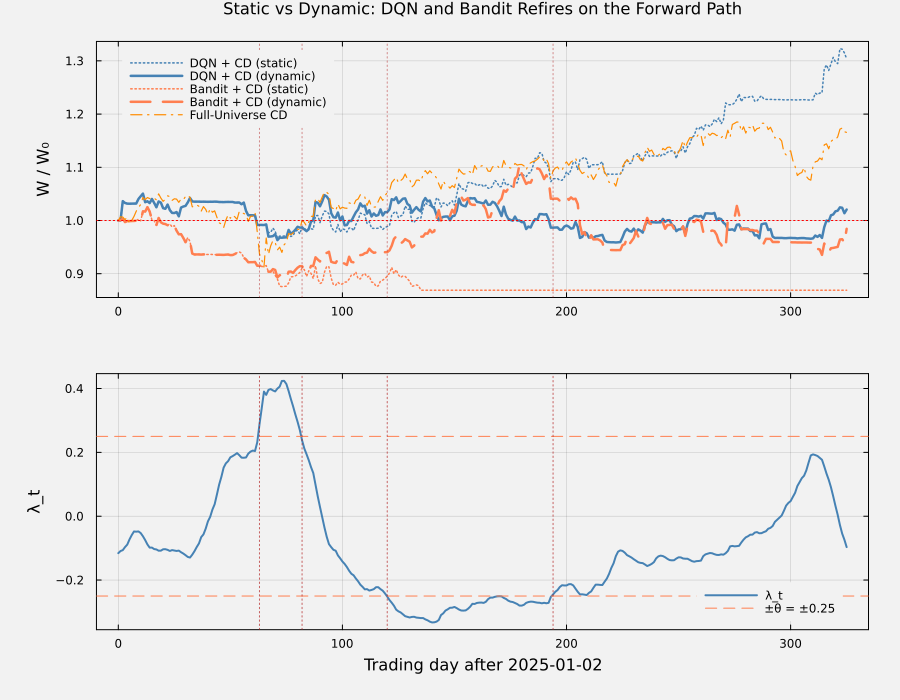

In [18]:
let
    n_fwd = length(forward_lambda)
    θ = RETRIGGER_LAMBDA_THRESH
    fire_idx = dynamic_results["fire_idx"]
    wealth_dqn_dyn    = dynamic_results["wealth_dqn_dynamic"]
    wealth_bandit_dyn = dynamic_results["wealth_bandit_dynamic"]

    p_top = plot(xlabel = "", ylabel = "W / W₀",
                 title = "Static vs Dynamic: DQN and Bandit Refires on the Forward Path",
                 titlefontsize = 11, legend = :topleft,
                 bg = "gray95", framestyle = :box, fg_legend = :transparent)
    plot!(p_top, 0:(n_fwd-1), forward_results["DQN + CD"]      ./ B₀; c = :steelblue,   lw = 1.5, ls = :dot,  label = "DQN + CD (static)")
    plot!(p_top, 0:(n_fwd-1), wealth_dqn_dyn                   ./ B₀; c = :steelblue,   lw = 2.5,             label = "DQN + CD (dynamic)")
    plot!(p_top, 0:(n_fwd-1), forward_results["Bandit + CD"]   ./ B₀; c = :coral,       lw = 1.5, ls = :dot,  label = "Bandit + CD (static)")
    plot!(p_top, 0:(n_fwd-1), wealth_bandit_dyn                ./ B₀; c = :coral,       lw = 2.5, ls = :dash, label = "Bandit + CD (dynamic)")
    plot!(p_top, 0:(n_fwd-1), forward_results["Full-Universe CD"] ./ B₀; c = :darkorange, lw = 1.2, ls = :dashdot, label = "Full-Universe CD")
    hline!(p_top, [1.0]; c = :red, ls = :dot, label = "")
    for t in fire_idx
        vline!(p_top, [t-1]; c = :firebrick, ls = :dot, alpha = 0.5, label = "")
    end

    p_bot = plot(0:(n_fwd-1), forward_lambda; lw = 2, c = :steelblue,
                 xlabel = "Trading day after $(Date(bandit_decision_date))",
                 ylabel = "λ_t", legend = :bottomright,
                 label = "λ_t",
                 bg = "gray95", framestyle = :box, fg_legend = :transparent)
    hline!(p_bot, [θ, -θ]; c = :coral, ls = :dash, label = "±θ = ±$(θ)")
    for t in fire_idx
        vline!(p_bot, [t-1]; c = :firebrick, ls = :dot, alpha = 0.7, label = "")
    end

    plot(p_top, p_bot; layout = (2, 1), size = (900, 700),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

___
## Summary
This advanced example scaled the Session 3 ticker-picker DQN to the full S&P 500 universe and added a sentiment-trigger refire protocol so the basket can change as the regime changes. The combinatorial bandit physically cannot store $2^{K}$ arm means at this $K$; we replaced it with a sparse-Dict variant constrained to size-$K_{\text{basket}}$ baskets, gave both pickers the same training-sample budget, and walked them through the same forward path with the same Cobb-Douglas rebalancer.

> __Key Takeaways:__
>
> * __Function approximation lets the picker scale where the table cannot:__ The dense bandit's storage cost grows with the number of subsets ($2^{K}$); the Q-network's storage cost is fixed by the architecture. At $K \approx 500$ the dense bandit cannot allocate its arm-mean vector at all, while the DQN's parameter count is independent of $K$ and shared weights generalize across baskets.
> * __The sparse-Dict bandit is the right baseline for production scale:__ Storing arm means only for visited baskets makes the bandit runnable, but with $\binom{K}{K_{\text{basket}}}$ possible arms and $\sim 10^{4}$ iterations, almost every iteration visits a fresh arm and `best_arm` becomes the best random sample. This makes the comparison apples-to-apples without pretending the dense bandit is feasible.
> * __Refiring on $|\lambda_t| = \theta$ closes the loop into Session 4's production cron:__ The same trigger logic from the bandit notebook applies to the DQN; both pickers retrain at each crossing and switch the basket on the fly. Whether dynamic beats static on the realized path is data-dependent, but the closed-loop variant is the version that scales into the production engine.

Two natural extensions, both inside the framework we built:
* __Featurized state for zero-shot redeploy.__ Concatenate per-ticker features ($\gamma_i$ at the current decision day, $\beta_i$, $\sigma_{\varepsilon, i}$, recent realized return) onto the basket-mask state. The Q-network then learns the FUNCTION (basket, context) $\to$ next pick, and at refire we re-query the same trained network with new $\gamma_i$ inputs computed at that day instead of retraining from scratch. The refire cost drops from `REFIRE_EPISODES` of training to a single forward pass.
* __Prioritized experience replay.__ Replace uniform sampling from the replay buffer with prioritized replay, sampling with probability proportional to $|y_i - [Q_{\boldsymbol{\theta}}(s_i)]_{a_i}|$. Convergence in Task 1 should be measurably faster, especially in the early phase before the network has discovered the high-$\gamma$ tickers.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use real historical data and simplified models.